<a href="https://colab.research.google.com/github/hoin1357/MachineLearning/blob/main/%EC%A4%91%EA%B0%84%20%EB%B0%9C%ED%91%9C/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터 폴더: /content/colab_실행용/data

검증 성능지표


,Metric,K,Value,Meaning
0,MAE,,3465.815217,평균 절대 오차입니다. 실제 방문객과 예측 방문객의 차이를 명 단위로 평균낸 값이며...
1,RMSE,,4854.682078,큰 오차에 더 큰 벌점을 주는 평균 오차입니다. 명 단위이며 낮을수록 좋습니다.
2,MAPE,,183.039917,평균 절대 백분율 오차입니다. 실제값 대비 예측 오차 비율이며 낮을수록 좋습니다.
3,R2,,0.703311,설명력 지표입니다. 1에 가까울수록 실제 방문객 변동을 잘 설명합니다.
4,Precision@K,5,1.000000,예측 상위 K일 중 실제 혼잡일이 얼마나 포함됐는지입니다. 높을수록 혼잡일 추천 정...
5,Recall@K,5,0.357143,전체 실제 혼잡일 중 예측 상위 K일이 얼마나 찾아냈는지입니다. 높을수록 놓친 혼잡...
6,NDCG@K,5,0.854937,상위 K일의 순위 품질입니다. 실제 방문객이 많은 날을 더 위에 배치할수록 1에 가...
7,Precision@K,10,0.900000,예측 상위 K일 중 실제 혼잡일이 얼마나 포함됐는지입니다. 높을수록 혼잡일 추천 정...
8,Recall@K,10,0.642857,전체 실제 혼잡일 중 예측 상위 K일이 얼마나 찾아냈는지입니다. 높을수록 놓친 혼잡...
9,NDCG@K,10,0.893144,상위 K일의 순위 품질입니다. 실제 방문객이 많은 날을 더 위에 배치할수록 1에 가...



검증 구간 예측 결과


,date,actual_visitors,predicted_visitors,actual_busy,predicted_rank,actual_rank
0,2025-05-01,2771.0,9953,False,24,50
1,2025-05-02,11903.0,18485,False,11,17
2,2025-05-03,7295.0,8089,False,31,25
3,2025-05-04,33907.0,26515,True,4,2
4,2025-05-05,38060.0,32987,True,2,1
5,2025-05-06,19169.0,39535,True,1,13
6,2025-05-07,3343.0,9676,False,27,39
7,2025-05-08,3929.0,8231,False,30,38
8,2025-05-09,2623.0,3961,False,59,51
9,2025-05-10,2241.0,5014,False,52,54



검증 예측 데이터 저장: /content/colab_실행용/data/artifacts/validation_predictions.csv
검증 성능지표 저장: /content/colab_실행용/data/artifacts/validation_metrics.csv
모델을 새로 학습하고 미래 예측 데이터를 만듭니다.

미래 예측 데이터 범위
2025-08-01 00:00:00 ~ 2027-04-23 00:00:00
미래 예측 데이터 저장: /content/colab_실행용/data/artifacts/portable_predictions.csv


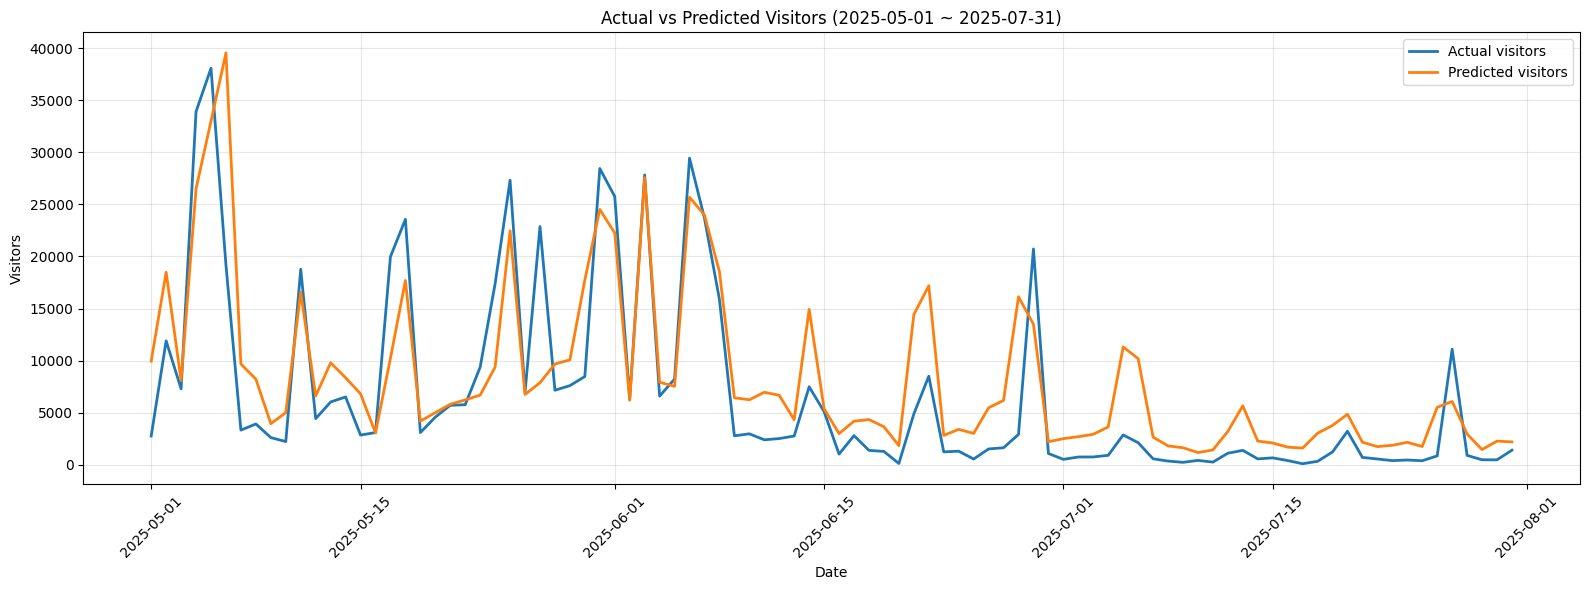

실제데이터-예측값 그래프 저장: /content/colab_실행용/data/artifacts/validation_actual_vs_predicted.png


In [2]:
# Google Colab 코드 셀 하나에 그대로 붙여넣고 실행하세요.
# 먼저 이 colab_실행용 폴더를 zip으로 압축해서 Colab에 업로드한 뒤 실행하면 됩니다.
# 이 파일은 웹페이지 표시용 코드 없이 모델 학습, 검증, 미래 예측, 그래프 출력만 포함합니다.

!pip -q install pandas numpy scikit-learn catboost holidayskr httpx matplotlib

import json
import os
import re
import shutil
import zipfile
from dataclasses import dataclass
from datetime import date, datetime, timedelta
from pathlib import Path
from zoneinfo import ZoneInfo

import holidayskr
import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from IPython.display import display
except ImportError:
    display = print


# ---------------------------------------------------------------------
# 1. Colab 폴더 준비
# ---------------------------------------------------------------------
# Colab에 업로드한 zip 이름이 달라도, 압축 안에 data/visitors.csv가 있으면 자동으로 찾습니다.
WORK_DIR = Path("/content/colab_실행용")
if not (WORK_DIR / "data" / "visitors.csv").exists():
    local_candidates = [Path.cwd(), Path.cwd() / "colab_실행용"]
    for candidate in local_candidates:
        if (candidate / "data" / "visitors.csv").exists():
            WORK_DIR = candidate
            break
if not (WORK_DIR / "data" / "visitors.csv").exists():
    zip_candidates = sorted(Path("/content").glob("*.zip"))
    if zip_candidates:
        extract_root = Path("/content/colab_upload")
        if extract_root.exists():
            shutil.rmtree(extract_root)
        extract_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_candidates[0], "r") as archive:
            archive.extractall(extract_root)
        matches = [
            path
            for path in extract_root.rglob("*")
            if path.is_dir() and (path / "data" / "visitors.csv").exists()
        ]
        if matches:
            WORK_DIR = matches[0]

DATA_DIR = WORK_DIR / "data"
WEATHER_HISTORY_DIR = DATA_DIR / "weather_history"
ARTIFACTS_DIR = DATA_DIR / "artifacts"
VISITORS_FILE = DATA_DIR / "visitors.csv"
EVENTS_FILE = DATA_DIR / "events.csv"
PREDICTION_CACHE_FILE = ARTIFACTS_DIR / "portable_predictions.csv"
PREDICTION_METADATA_FILE = ARTIFACTS_DIR / "portable_predictions_metadata.json"
WEATHER_CACHE_FILE = ARTIFACTS_DIR / "weather_api_cache.json"
VALIDATION_PREDICTIONS_FILE = ARTIFACTS_DIR / "validation_predictions.csv"
VALIDATION_METRICS_FILE = ARTIFACTS_DIR / "validation_metrics.csv"
VALIDATION_GRAPH_FILE = ARTIFACTS_DIR / "validation_actual_vs_predicted.png"

required_paths = [VISITORS_FILE, EVENTS_FILE, WEATHER_HISTORY_DIR]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("필수 데이터가 없습니다:\n" + "\n".join(missing_paths))

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"데이터 폴더: {DATA_DIR}")


# ---------------------------------------------------------------------
# 2. 설정값
# ---------------------------------------------------------------------
SEOUL_TIMEZONE = ZoneInfo("Asia/Seoul")
TODAY = datetime.now(SEOUL_TIMEZONE).date()

# 예측할 미래 범위입니다. 365면 오늘부터 1년 뒤까지 예측합니다.
FORECAST_HORIZON_DAYS = 365

# 검증 구간입니다. 이 기간 직전 데이터까지만 학습하고, 이 구간의 실제 방문객과 예측값을 비교합니다.
VALIDATION_START = "2025-05-01"
VALIDATION_END = "2025-07-31"

# 공공데이터포털 기상청 API 인증키와 endpoint입니다.
WEATHER_API_SERVICE_KEY = "662b6272fdcb5ce6acda46179c67f38edc18d32bbe617cfd8db4d58941eaf890"
WEATHER_API_BASE_URL = "https://apis.data.go.kr/1360000/VilageFcstInfoService_2.0"
MID_WEATHER_API_BASE_URL = "https://apis.data.go.kr/1360000/MidFcstInfoService"

# 단기예보 격자 좌표입니다. 서울대공원 주변 격자입니다.
WEATHER_GRID_X = 60
WEATHER_GRID_Y = 124

# 중기예보 지역코드입니다. 기온은 과천, 육상예보는 서울/인천/경기 권역을 사용합니다.
MID_TEMPERATURE_REGION_ID = "11B10102"
MID_LAND_REGION_ID = "11B00000"

# 날씨 로직이 바뀌면 캐시를 새로 만들기 위한 버전값입니다.
WEATHER_STRATEGY_VERSION = "short-mid-v1"

# 방문객 수 상위 몇 %를 "혼잡일"로 볼지 정합니다.
# 0.15는 검증/분류용으로 방문객 상위 15% 날짜를 혼잡일로 본다는 뜻입니다.
BUSY_LABEL_RATIO = 0.15

# 방문객이 많은 날을 더 중요하게 맞추기 위한 학습 가중치입니다.
# 상위 10% 날짜에는 4배, 상위 20% 날짜에는 2배 가중치를 줍니다.
TOP_10_WEIGHT = 4.0
TOP_20_WEIGHT = 2.0

# 1단계 CatBoostClassifier 설정입니다.
# 목적: 방문객 수 자체를 바로 맞추기 전에 "혼잡일일 가능성"을 먼저 예측합니다.
CLASSIFIER_PARAMS = {
    "loss_function": "Logloss",       # 이진 분류 손실함수입니다.
    "depth": 6,                       # 트리 깊이입니다. 클수록 복잡한 패턴을 잡지만 과적합 위험이 커집니다.
    "learning_rate": 0.05,            # 한 번에 학습하는 보폭입니다. 작을수록 안정적이지만 더 많은 반복이 필요합니다.
    "iterations": 500,                # 생성할 트리 개수입니다.
    "l2_leaf_reg": 3.0,               # 과적합을 줄이는 L2 규제 강도입니다.
    "random_seed": 42,                # 재현 가능한 결과를 위한 난수 seed입니다.
    "verbose": False,                 # Colab 출력이 너무 길어지지 않도록 학습 로그를 끕니다.
    "allow_writing_files": False,     # CatBoost가 별도 학습 로그 파일을 만들지 않게 합니다.
}

# 2단계 CatBoostRegressor 설정입니다.
# 목적: 1단계 혼잡일 확률까지 feature로 넣어 최종 방문객 수를 예측합니다.
REGRESSOR_PARAMS = {
    "loss_function": "RMSE",          # 회귀 모델이 최소화할 오차 기준입니다.
    "depth": 8,                       # 회귀 모델은 조금 더 복잡한 패턴을 잡도록 분류기보다 깊게 둡니다.
    "learning_rate": 0.05,            # 학습 보폭입니다.
    "iterations": 800,                # 트리 개수입니다. 데이터가 많지 않아 과도하게 키우지 않습니다.
    "l2_leaf_reg": 5.0,               # 회귀 모델 과적합 방지를 위한 규제입니다.
    "random_seed": 42,                # 재현 가능한 결과를 위한 seed입니다.
    "verbose": False,
    "allow_writing_files": False,
}

# 방문객 원본 데이터의 긴 결측 구간을 채우기 위한 보정 회귀 모델입니다.
IMPUTATION_MODEL_PARAMS = {
    "loss_function": "RMSE",
    "depth": 6,
    "learning_rate": 0.05,
    "iterations": 700,
    "l2_leaf_reg": 5.0,
    "min_data_in_leaf": 5,            # 잎 노드에 들어갈 최소 데이터 수입니다. 작을수록 세밀하지만 과적합 위험이 있습니다.
    "random_strength": 1.0,           # 트리 분기 선택에 무작위성을 더해 과적합을 줄입니다.
    "verbose": False,
    "random_seed": 42,
    "allow_writing_files": False,
}

SEASON_COLUMNS = [
    "벚꽃행사시즌",
    "야간개장시즌",
    "어린이행사시즌",
    "가을축제시즌",
]


# ---------------------------------------------------------------------
# 3. 행사/시즌 feature 생성
# ---------------------------------------------------------------------
def parse_event_period(event_text: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    matches = re.findall(r"(\d{4}\.\d{2}\.\d{2})", event_text)
    if not matches:
        raise ValueError(f"행사 날짜를 파싱할 수 없습니다: {event_text}")
    start_date = pd.to_datetime(matches[0], format="%Y.%m.%d")
    end_date = pd.to_datetime(matches[1], format="%Y.%m.%d") if len(matches) > 1 else start_date
    return start_date, end_date


def classify_event_name(event_text: str) -> str | None:
    lowered = event_text.replace(" ", "")
    if any(keyword in lowered for keyword in ["벚꽃", "봄꽃", "장미원", "꽃의숲", "정원", "식물원축제", "장미,정원을품다"]):
        return "벚꽃행사시즌"
    if any(keyword in lowered for keyword in ["어린이", "어린이날", "주(zoo)인공"]):
        return "어린이행사시즌"
    if any(keyword in lowered for keyword in ["영화제", "호숫가영화제", "야간", "하이킹"]):
        return "야간개장시즌"
    if any(keyword in lowered for keyword in ["한가위", "가을", "미술관", "동물원밖동물원", "숲속콘서트", "동물서식지문화축제", "동물원큰잔치"]):
        return "가을축제시즌"
    return None


@dataclass
class EventSeasonService:
    historical_daily_flags: pd.DataFrame
    recurring_day_of_year: dict[str, set[int]]

    @classmethod
    def from_csv(cls, events_file: str | os.PathLike[str]) -> "EventSeasonService":
        events = pd.read_csv(events_file)
        daily_records = []
        recurring_day_of_year = {season: set() for season in SEASON_COLUMNS}

        for event_text in events["행사이름 - 날짜"].astype(str):
            season = classify_event_name(event_text)
            if not season:
                continue
            start_date, end_date = parse_event_period(event_text)
            for current_date in pd.date_range(start_date, end_date, freq="D"):
                daily_records.append({"일자": current_date, season: 1})
                recurring_day_of_year[season].add(int(current_date.strftime("%j")))

        if daily_records:
            daily_flags = pd.DataFrame(daily_records).groupby("일자", as_index=False).max()
        else:
            daily_flags = pd.DataFrame({"일자": []})

        for season in SEASON_COLUMNS:
            if season not in daily_flags.columns:
                daily_flags[season] = 0

        daily_flags["season_active_count"] = daily_flags[SEASON_COLUMNS].sum(axis=1)
        return cls(daily_flags.sort_values("일자").reset_index(drop=True), recurring_day_of_year)

    def merge_historical_flags(self, frame: pd.DataFrame) -> pd.DataFrame:
        merged = frame.merge(self.historical_daily_flags, on="일자", how="left")
        for season in SEASON_COLUMNS:
            merged[season] = merged[season].fillna(0).astype(int)
        merged["season_active_count"] = merged["season_active_count"].fillna(0).astype(int)
        return merged

    def recurring_flags_for_date(self, target_date: date) -> dict[str, int]:
        day_of_year = int(target_date.strftime("%j"))
        flags = {season: int(day_of_year in self.recurring_day_of_year[season]) for season in SEASON_COLUMNS}
        flags["season_active_count"] = sum(flags.values())
        return flags


# ---------------------------------------------------------------------
# 4. 날씨 feature 생성
# ---------------------------------------------------------------------
@dataclass
class DailyWeatherFeature:
    average_temperature: float
    average_precipitation: float
    source: str


class WeatherService:
    def __init__(self, weather_history_dir: Path) -> None:
        self.weather_history_dir = weather_history_dir
        self.weather_history = self._load_history()
        self.by_month_day = self.weather_history.groupby("month_day", as_index=False).agg(
            average_temperature=("평균기온", "mean"),
            average_precipitation=("일강수량", "mean"),
        )
        self.by_month = self.weather_history.groupby("month", as_index=False).agg(
            average_temperature=("평균기온", "mean"),
            average_precipitation=("일강수량", "mean"),
        )
        self.api_cache = self._load_api_cache()

    def _load_history(self) -> pd.DataFrame:
        frames = []
        for csv_path in sorted(self.weather_history_dir.glob("*.csv")):
            frame = pd.read_csv(csv_path, encoding="cp949")
            frame["일자"] = pd.to_datetime(frame["일시"])
            frame["평균기온"] = pd.to_numeric(frame["평균기온(°C)"], errors="coerce")
            frame["일강수량"] = pd.to_numeric(frame["일강수량(mm)"], errors="coerce").fillna(0.0)
            frames.append(frame[["일자", "평균기온", "일강수량"]])
        weather = pd.concat(frames, ignore_index=True).sort_values("일자").reset_index(drop=True)
        weather["평균기온"] = weather["평균기온"].interpolate(limit_direction="both")
        weather["month_day"] = weather["일자"].dt.strftime("%m-%d")
        weather["month"] = weather["일자"].dt.month
        return weather

    def _load_api_cache(self) -> dict[str, dict[str, float | str]]:
        if WEATHER_CACHE_FILE.exists():
            return json.loads(WEATHER_CACHE_FILE.read_text(encoding="utf-8"))
        return {}

    def _save_api_cache(self) -> None:
        ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
        WEATHER_CACHE_FILE.write_text(json.dumps(self.api_cache, ensure_ascii=False, indent=2), encoding="utf-8")

    def _forecast_base_datetime(self, now: datetime) -> tuple[str, str]:
        base_times = ["0200", "0500", "0800", "1100", "1400", "1700", "2000", "2300"]
        hhmm = int(now.strftime("%H%M"))
        base_time = "2300"
        base_date = now.date()
        for candidate in base_times:
            if hhmm >= int(candidate) + 10:
                base_time = candidate
        if hhmm < 210:
            base_date = now.date() - timedelta(days=1)
            base_time = "2300"
        return base_date.strftime("%Y%m%d"), base_time

    def _mid_forecast_base_datetime(self, now: datetime) -> datetime:
        seoul_now = now.astimezone(SEOUL_TIMEZONE) if now.tzinfo else now.replace(tzinfo=SEOUL_TIMEZONE)
        if seoul_now.hour >= 18:
            return seoul_now.replace(hour=18, minute=0, second=0, microsecond=0)
        if seoul_now.hour >= 6:
            return seoul_now.replace(hour=6, minute=0, second=0, microsecond=0)
        return (seoul_now - timedelta(days=1)).replace(hour=18, minute=0, second=0, microsecond=0)

    def _parse_precipitation(self, raw_value: str) -> float:
        value = raw_value.strip()
        if value in {"강수없음", "0", "0.0"}:
            return 0.0
        if "1mm 미만" in value:
            return 0.5
        if "~" in value:
            numbers = [float(part.strip()) for part in value.replace("mm", "").split("~") if part.strip()]
            if len(numbers) == 2:
                return sum(numbers) / 2
        try:
            return float(value.replace("mm", "").strip())
        except ValueError:
            return 0.0

    def _extract_items(self, body: dict) -> list[dict]:
        response = body.get("response", {})
        header = response.get("header", {})
        if header.get("resultCode") != "00":
            raise ValueError(header.get("resultMsg") or "날씨 API 응답이 정상 상태가 아닙니다.")
        items = response.get("body", {}).get("items", {}).get("item", [])
        if isinstance(items, dict):
            return [items]
        if not isinstance(items, list):
            raise ValueError("날씨 API 응답 item 형식이 올바르지 않습니다.")
        return items

    def _precipitation_from_mid_forecast(
        self,
        morning_probability: float,
        afternoon_probability: float,
        *weather_texts: str,
    ) -> float:
        probability = (morning_probability + afternoon_probability) / 2
        weather_text = " ".join(text for text in weather_texts if text)
        has_wet_weather = any(keyword in weather_text for keyword in ("비", "눈", "소나기"))
        if not has_wet_weather:
            return 0.0 if probability < 50 else 0.5
        base_amount = 3.0 if ("눈" in weather_text and "비" not in weather_text) else 5.0
        if "많" in weather_text or "강" in weather_text:
            base_amount = 8.0
        return round(base_amount * (probability / 100), 2)

    def _fetch_short_forecast_block(self) -> dict[str, DailyWeatherFeature]:
        now = datetime.now(SEOUL_TIMEZONE)
        base_date, base_time = self._forecast_base_datetime(now)
        params = {
            "serviceKey": WEATHER_API_SERVICE_KEY,
            "pageNo": 1,
            "numOfRows": 1000,
            "dataType": "JSON",
            "base_date": base_date,
            "base_time": base_time,
            "nx": WEATHER_GRID_X,
            "ny": WEATHER_GRID_Y,
        }
        url = f"{WEATHER_API_BASE_URL}/getVilageFcst"
        forecast_by_date = {}
        with httpx.Client(timeout=8.0) as client:
            response = client.get(url, params=params)
            response.raise_for_status()
            items = self._extract_items(response.json())
        for item in items:
            fcst_date = str(item["fcstDate"])
            forecast_by_date.setdefault(fcst_date, {"TMP": [], "PCP": []})
            if item["category"] == "TMP":
                forecast_by_date[fcst_date]["TMP"].append(float(item["fcstValue"]))
            elif item["category"] == "PCP":
                forecast_by_date[fcst_date]["PCP"].append(self._parse_precipitation(str(item["fcstValue"])))

        transformed = {}
        for key, values in forecast_by_date.items():
            if not values["TMP"]:
                continue
            transformed[pd.to_datetime(key, format="%Y%m%d").date().isoformat()] = DailyWeatherFeature(
                average_temperature=float(sum(values["TMP"]) / len(values["TMP"])),
                average_precipitation=float(sum(values["PCP"]) / len(values["PCP"])) if values["PCP"] else 0.0,
                source="forecast",
            )
        return transformed

    def _fetch_mid_forecast_block(self) -> dict[str, DailyWeatherFeature]:
        base_datetime = self._mid_forecast_base_datetime(datetime.now(SEOUL_TIMEZONE))
        common_params = {
            "serviceKey": WEATHER_API_SERVICE_KEY,
            "pageNo": 1,
            "numOfRows": 10,
            "dataType": "JSON",
            "tmFc": base_datetime.strftime("%Y%m%d%H%M"),
        }
        with httpx.Client(timeout=8.0) as client:
            temperature_response = client.get(
                f"{MID_WEATHER_API_BASE_URL}/getMidTa",
                params={**common_params, "regId": MID_TEMPERATURE_REGION_ID},
            )
            temperature_response.raise_for_status()
            temperature_items = self._extract_items(temperature_response.json())
            land_response = client.get(
                f"{MID_WEATHER_API_BASE_URL}/getMidLandFcst",
                params={**common_params, "regId": MID_LAND_REGION_ID},
            )
            land_response.raise_for_status()
            land_items = self._extract_items(land_response.json())

        if not temperature_items or not land_items:
            return {}

        temperature_item = temperature_items[0]
        land_item = land_items[0]
        transformed = {}
        for day_offset in (4, 5):
            min_key = f"taMin{day_offset}"
            max_key = f"taMax{day_offset}"
            if min_key not in temperature_item or max_key not in temperature_item:
                continue
            rn_am = float(land_item.get(f"rnSt{day_offset}Am", 0))
            rn_pm = float(land_item.get(f"rnSt{day_offset}Pm", 0))
            target_date = base_datetime.date() + timedelta(days=day_offset)
            transformed[target_date.isoformat()] = DailyWeatherFeature(
                average_temperature=(float(temperature_item[min_key]) + float(temperature_item[max_key])) / 2,
                average_precipitation=self._precipitation_from_mid_forecast(
                    rn_am,
                    rn_pm,
                    str(land_item.get(f"wf{day_offset}Am", "")),
                    str(land_item.get(f"wf{day_offset}Pm", "")),
                ),
                source="mid_forecast",
            )
        return transformed

    def _fetch_forecast_block(self) -> dict[str, DailyWeatherFeature]:
        cache_key = f"{TODAY.isoformat()}:{WEATHER_STRATEGY_VERSION}"
        if cache_key in self.api_cache:
            return {
                key: DailyWeatherFeature(
                    average_temperature=value["average_temperature"],
                    average_precipitation=value["average_precipitation"],
                    source=value["source"],
                )
                for key, value in self.api_cache[cache_key].items()
            }

        transformed = {}
        for fetcher in (self._fetch_mid_forecast_block, self._fetch_short_forecast_block):
            try:
                transformed.update(fetcher())
            except Exception:
                continue
        if not transformed:
            raise ValueError("사용 가능한 날씨 API 예보가 없습니다.")

        self.api_cache[cache_key] = {
            key: {
                "average_temperature": value.average_temperature,
                "average_precipitation": value.average_precipitation,
                "source": value.source,
            }
            for key, value in transformed.items()
        }
        self._save_api_cache()
        return transformed

    def _climatology_for_date(self, target_date: date) -> DailyWeatherFeature:
        month_day = target_date.strftime("%m-%d")
        match = self.by_month_day.loc[self.by_month_day["month_day"] == month_day]
        if not match.empty:
            row = match.iloc[0]
            return DailyWeatherFeature(float(row["average_temperature"]), float(row["average_precipitation"]), "climatology")
        row = self.by_month.loc[self.by_month["month"] == target_date.month].iloc[0]
        return DailyWeatherFeature(float(row["average_temperature"]), float(row["average_precipitation"]), "climatology")

    def feature_for_date(self, target_date: date) -> DailyWeatherFeature:
        if target_date < TODAY:
            row = self.weather_history.loc[self.weather_history["일자"] == pd.Timestamp(target_date)]
            if not row.empty:
                row = row.iloc[0]
                return DailyWeatherFeature(float(row["평균기온"]), float(row["일강수량"]), "historical")

        if target_date <= TODAY + timedelta(days=5):
            try:
                forecast_block = self._fetch_forecast_block()
                if target_date.isoformat() in forecast_block:
                    return forecast_block[target_date.isoformat()]
            except Exception:
                pass
        return self._climatology_for_date(target_date)


# ---------------------------------------------------------------------
# 5. 모델 feature 목록
# ---------------------------------------------------------------------
FEATURE_COLUMNS = [
    "년", "월", "일", "요일번호", "주말여부", "분기", "연중일수", "연중주차", "시작후경과일",
    "월_sin", "월_cos", "연중일수_sin", "연중일수_cos", "공휴일여부", "주말또는공휴일여부",
    "평균기온", "일강수량", "강수여부", "폭우여부", "한파일수", "무더위일수",
    *SEASON_COLUMNS, "season_active_count",
    "지연값_1", "지연값_7", "지연값_30", "지연값_365", "이동평균_7", "이동평균_30",
    "이동표준편차_7", "이동표준편차_30",
]

IMPUTATION_FEATURES = [
    "년", "월", "일", "요일번호", "주말여부", "분기", "연중일수", "연중주차", "시작후경과일",
    "월_sin", "월_cos", "연중일수_sin", "연중일수_cos", "공휴일여부", "주말또는공휴일여부",
    "평균기온", "일강수량", "강수여부", "폭우여부", "한파일수", "무더위일수",
    *SEASON_COLUMNS, "season_active_count",
]


# ---------------------------------------------------------------------
# 6. 모델 학습, 검증, 예측
# ---------------------------------------------------------------------
class SeoulGrandParkModel:
    def __init__(self) -> None:
        self.weather_service = WeatherService(WEATHER_HISTORY_DIR)
        self.event_service = EventSeasonService.from_csv(EVENTS_FILE)
        self.known_data_end: date | None = None
        self.prediction_frame: pd.DataFrame | None = None

    @property
    def max_supported_date(self) -> date:
        if self.prediction_frame is not None and not self.prediction_frame.empty:
            return self.prediction_frame["date"].max().date()
        return TODAY + timedelta(days=FORECAST_HORIZON_DAYS)

    def load_cache(self) -> bool:
        if not PREDICTION_CACHE_FILE.exists() or not PREDICTION_METADATA_FILE.exists():
            return False
        metadata = json.loads(PREDICTION_METADATA_FILE.read_text(encoding="utf-8"))
        if metadata.get("today") != TODAY.isoformat():
            return False
        if metadata.get("weather_strategy_version") != WEATHER_STRATEGY_VERSION:
            return False
        prediction_frame = pd.read_csv(PREDICTION_CACHE_FILE, parse_dates=["date"])
        if prediction_frame.empty or prediction_frame["date"].max().date() < TODAY:
            return False
        self.known_data_end = pd.to_datetime(metadata["known_data_end"]).date()
        self.prediction_frame = prediction_frame
        return True

    def save_cache(self) -> None:
        assert self.prediction_frame is not None
        self.prediction_frame.to_csv(PREDICTION_CACHE_FILE, index=False, encoding="utf-8-sig")
        PREDICTION_METADATA_FILE.write_text(
            json.dumps(
                {
                    "today": TODAY.isoformat(),
                    "known_data_end": self.known_data_end.isoformat(),
                    "horizon_days": FORECAST_HORIZON_DAYS,
                    "weather_strategy_version": WEATHER_STRATEGY_VERSION,
                },
                ensure_ascii=False,
                indent=2,
            ),
            encoding="utf-8",
        )

    def initialize(self, force_retrain: bool = False) -> None:
        if not force_retrain and self.load_cache():
            print("기존 미래 예측 캐시를 불러왔습니다.")
            return
        print("모델을 새로 학습하고 미래 예측 데이터를 만듭니다.")
        self.prediction_frame = self.build_prediction_frame()
        self.save_cache()

    def load_visitors(self) -> pd.DataFrame:
        visitors = pd.read_csv(VISITORS_FILE)
        visitors["일자"] = pd.to_datetime(visitors["일자"].astype(str))
        visitors = visitors.sort_values("일자").reset_index(drop=True)
        self.known_data_end = visitors.loc[visitors["방문인원수"].notna(), "일자"].max().date()
        return visitors

    def add_calendar_features(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        dataframe = dataframe.copy()
        dataframe["년"] = dataframe["일자"].dt.year
        dataframe["월"] = dataframe["일자"].dt.month
        dataframe["일"] = dataframe["일자"].dt.day
        dataframe["요일번호"] = dataframe["일자"].dt.dayofweek
        dataframe["주말여부"] = (dataframe["요일번호"] >= 5).astype(int)
        dataframe["분기"] = dataframe["일자"].dt.quarter
        dataframe["연중일수"] = dataframe["일자"].dt.dayofyear
        dataframe["연중주차"] = dataframe["일자"].dt.isocalendar().week.astype(int)
        dataframe["시작후경과일"] = (dataframe["일자"] - dataframe["일자"].min()).dt.days
        dataframe["월_sin"] = np.sin(2 * np.pi * dataframe["월"] / 12)
        dataframe["월_cos"] = np.cos(2 * np.pi * dataframe["월"] / 12)
        dataframe["연중일수_sin"] = np.sin(2 * np.pi * dataframe["연중일수"] / 365.25)
        dataframe["연중일수_cos"] = np.cos(2 * np.pi * dataframe["연중일수"] / 365.25)
        dataframe["공휴일여부"] = dataframe["일자"].dt.strftime("%Y-%m-%d").map(lambda text: int(holidayskr.is_holiday(text)))
        dataframe["주말또는공휴일여부"] = ((dataframe["주말여부"] == 1) | (dataframe["공휴일여부"] == 1)).astype(int)
        return dataframe

    def add_weather_derived_features(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        dataframe = dataframe.copy()
        dataframe["강수여부"] = (dataframe["일강수량"] > 0).astype(int)
        dataframe["폭우여부"] = (dataframe["일강수량"] >= 10).astype(int)
        dataframe["한파일수"] = (dataframe["평균기온"] <= 0).astype(int)
        dataframe["무더위일수"] = (dataframe["평균기온"] >= 30).astype(int)
        return dataframe

    def fill_missing_visitors(self, visitors: pd.DataFrame) -> pd.DataFrame:
        frame = visitors.copy()
        frame = frame.merge(
            self.weather_service.weather_history[["일자", "평균기온", "일강수량"]],
            on="일자",
            how="left",
        )
        frame = self.event_service.merge_historical_flags(frame)
        frame = self.add_calendar_features(frame)
        frame = self.add_weather_derived_features(frame)

        single_missing_date = pd.Timestamp("2019-09-07")
        yearly_mask = (frame["년"] == 2019) & frame["방문인원수"].notna()
        weekday_code = int(single_missing_date.dayofweek)
        yearly_average = frame.loc[yearly_mask, "방문인원수"].mean()
        weekday_average = frame.loc[yearly_mask & (frame["요일번호"] == weekday_code), "방문인원수"].mean()
        frame.loc[frame["일자"] == single_missing_date, "방문인원수"] = round((yearly_average + weekday_average) / 2)

        long_gap_mask = frame["일자"].between(pd.Timestamp("2016-12-18"), pd.Timestamp("2017-03-29"))
        train_mask = frame["방문인원수"].notna() & (~long_gap_mask)
        imputation_model = CatBoostRegressor(**IMPUTATION_MODEL_PARAMS)
        imputation_model.fit(frame.loc[train_mask, IMPUTATION_FEATURES], frame.loc[train_mask, "방문인원수"])
        predicted_gap_values = imputation_model.predict(frame.loc[long_gap_mask, IMPUTATION_FEATURES])
        frame.loc[long_gap_mask, "방문인원수"] = np.maximum(np.round(predicted_gap_values), 0).astype(int)
        frame["방문인원수"] = frame["방문인원수"].round().astype(int)
        return frame

    def make_busy_sample_weights(self, target_values: pd.Series) -> np.ndarray:
        target_values = target_values.reset_index(drop=True)
        top_10_count = max(1, int(np.ceil(len(target_values) * 0.10)))
        top_20_count = max(top_10_count, int(np.ceil(len(target_values) * 0.20)))
        weights = pd.Series(1.0, index=target_values.index, dtype=float)
        weights.loc[target_values.nlargest(top_20_count).index] = TOP_20_WEIGHT
        weights.loc[target_values.nlargest(top_10_count).index] = TOP_10_WEIGHT
        return weights.to_numpy()

    def make_stage1_busy_labels(self, target_values: pd.Series) -> pd.Series:
        target_values = target_values.reset_index(drop=True)
        busy_count = max(1, int(np.ceil(len(target_values) * BUSY_LABEL_RATIO)))
        labels = pd.Series(0, index=target_values.index, dtype=int)
        labels.loc[target_values.nlargest(busy_count).index] = 1
        return labels

    def append_stage1_outputs(self, classifier: CatBoostClassifier, frame: pd.DataFrame) -> pd.DataFrame:
        probabilities = classifier.predict_proba(frame)[:, 1]
        augmented = frame.copy()
        augmented["혼잡일확률"] = probabilities
        augmented["혼잡일예측라벨"] = (probabilities >= 0.5).astype(int)
        return augmented

    def train_models(self, frame: pd.DataFrame) -> tuple[CatBoostClassifier, CatBoostRegressor, pd.Series]:
        features = frame[FEATURE_COLUMNS]
        target = frame["방문인원수"]
        train_medians = features.median(numeric_only=True)
        filled_features = features.fillna(train_medians)
        classifier = CatBoostClassifier(**CLASSIFIER_PARAMS)
        classifier.fit(filled_features, self.make_stage1_busy_labels(target))
        augmented = self.append_stage1_outputs(classifier, filled_features)
        regressor = CatBoostRegressor(**REGRESSOR_PARAMS)
        regressor.fit(augmented, target, sample_weight=self.make_busy_sample_weights(target))
        return classifier, regressor, train_medians

    def build_base_training_frame(self, filled_visitors: pd.DataFrame) -> pd.DataFrame:
        history = filled_visitors[["일자", "방문인원수"]].copy()
        history = self.event_service.merge_historical_flags(history)
        history = history.merge(
            self.weather_service.weather_history[["일자", "평균기온", "일강수량"]],
            on="일자",
            how="left",
        )
        history = self.add_calendar_features(history)
        history = self.add_weather_derived_features(history)
        history["지연값_1"] = history["방문인원수"].shift(1)
        history["지연값_7"] = history["방문인원수"].shift(7)
        history["지연값_30"] = history["방문인원수"].shift(30)
        history["지연값_365"] = history["방문인원수"].shift(365)
        previous = history["방문인원수"].shift(1)
        history["이동평균_7"] = previous.rolling(window=7).mean()
        history["이동평균_30"] = previous.rolling(window=30).mean()
        history["이동표준편차_7"] = previous.rolling(window=7).std()
        history["이동표준편차_30"] = previous.rolling(window=30).std()
        return history

    def predict_future_rows(
        self,
        classifier: CatBoostClassifier,
        regressor: CatBoostRegressor,
        train_medians: pd.Series,
        series_frame: pd.DataFrame,
        start_date: date,
        end_date: date,
    ) -> pd.DataFrame:
        future_rows = []
        current_date = pd.Timestamp(start_date)
        end_timestamp = pd.Timestamp(end_date)

        while current_date <= end_timestamp:
            weather = self.weather_service.feature_for_date(current_date.date())
            recurring_flags = self.event_service.recurring_flags_for_date(current_date.date())
            row = {
                "일자": current_date,
                "방문인원수": np.nan,
                "평균기온": weather.average_temperature,
                "일강수량": weather.average_precipitation,
                **recurring_flags,
            }
            row_frame = pd.DataFrame([row])
            row_frame = self.add_calendar_features(row_frame)
            row_frame = self.add_weather_derived_features(row_frame)

            history_values = series_frame["방문인원수"]
            row_frame["지연값_1"] = history_values.iloc[-1]
            row_frame["지연값_7"] = history_values.iloc[-7] if len(history_values) >= 7 else np.nan
            row_frame["지연값_30"] = history_values.iloc[-30] if len(history_values) >= 30 else np.nan
            row_frame["지연값_365"] = history_values.iloc[-365] if len(history_values) >= 365 else np.nan
            row_frame["이동평균_7"] = history_values.iloc[-7:].mean() if len(history_values) >= 7 else np.nan
            row_frame["이동평균_30"] = history_values.iloc[-30:].mean() if len(history_values) >= 30 else np.nan
            row_frame["이동표준편차_7"] = history_values.iloc[-7:].std() if len(history_values) >= 7 else np.nan
            row_frame["이동표준편차_30"] = history_values.iloc[-30:].std() if len(history_values) >= 30 else np.nan

            filled_features = row_frame[FEATURE_COLUMNS].fillna(train_medians)
            stage1_augmented = self.append_stage1_outputs(classifier, filled_features)
            predicted_visitors = int(max(round(regressor.predict(stage1_augmented)[0]), 0))

            future_rows.append(
                {
                    "date": current_date,
                    "predicted_visitors": predicted_visitors,
                    "busy_probability": float(stage1_augmented["혼잡일확률"].iloc[0]),
                    "weather_source": weather.source,
                    "average_temperature": weather.average_temperature,
                    "average_precipitation": weather.average_precipitation,
                    **recurring_flags,
                }
            )
            series_frame.loc[len(series_frame)] = {"일자": current_date, "방문인원수": predicted_visitors}
            current_date += timedelta(days=1)

        return pd.DataFrame(future_rows)

    def build_prediction_frame(self) -> pd.DataFrame:
        visitors = self.load_visitors()
        filled_visitors = self.fill_missing_visitors(visitors)
        history = self.build_base_training_frame(filled_visitors)
        classifier, regressor, train_medians = self.train_models(history)
        start_date = self.known_data_end + timedelta(days=1)
        end_date = TODAY + timedelta(days=FORECAST_HORIZON_DAYS)
        return self.predict_future_rows(
            classifier,
            regressor,
            train_medians,
            history[["일자", "방문인원수"]].copy(),
            start_date,
            end_date,
        )

    def build_prediction_frame_for_period(self, history_end_date: date, prediction_end_date: date) -> pd.DataFrame:
        visitors = pd.read_csv(VISITORS_FILE)
        visitors["일자"] = pd.to_datetime(visitors["일자"].astype(str))
        visitors = visitors.sort_values("일자").reset_index(drop=True)
        training_visitors = visitors.loc[visitors["일자"] <= pd.Timestamp(history_end_date)].copy()
        self.known_data_end = training_visitors.loc[training_visitors["방문인원수"].notna(), "일자"].max().date()
        filled_visitors = self.fill_missing_visitors(training_visitors)
        history = self.build_base_training_frame(filled_visitors)
        classifier, regressor, train_medians = self.train_models(history)
        return self.predict_future_rows(
            classifier,
            regressor,
            train_medians,
            history[["일자", "방문인원수"]].copy(),
            history_end_date + timedelta(days=1),
            prediction_end_date,
        )

    def evaluate_validation_period(
        self,
        validation_start: str = VALIDATION_START,
        validation_end: str = VALIDATION_END,
        k_values: tuple[int, ...] = (5, 10, 20),
        busy_ratio: float = BUSY_LABEL_RATIO,
    ) -> tuple[pd.DataFrame, pd.DataFrame]:
        validation_start_date = date.fromisoformat(validation_start)
        validation_end_date = date.fromisoformat(validation_end)
        history_end_date = validation_start_date - timedelta(days=1)
        prediction_frame = self.build_prediction_frame_for_period(history_end_date, validation_end_date)

        visitors = pd.read_csv(VISITORS_FILE)
        visitors["일자"] = pd.to_datetime(visitors["일자"].astype(str))
        actual = visitors.loc[
            visitors["일자"].between(pd.Timestamp(validation_start_date), pd.Timestamp(validation_end_date))
            & visitors["방문인원수"].notna(),
            ["일자", "방문인원수"],
        ].copy()
        actual = actual.rename(columns={"일자": "date", "방문인원수": "actual_visitors"})

        evaluation = prediction_frame.merge(actual, on="date", how="inner")
        if evaluation.empty:
            raise ValueError("검증 구간에 실제 방문객 데이터가 없습니다.")

        actual_values = evaluation["actual_visitors"].astype(float)
        predicted_values = evaluation["predicted_visitors"].astype(float)
        mae = mean_absolute_error(actual_values, predicted_values)
        rmse = mean_squared_error(actual_values, predicted_values) ** 0.5
        mape = (np.abs((actual_values - predicted_values) / actual_values.clip(lower=1))).mean() * 100
        r2 = r2_score(actual_values, predicted_values)

        actual_busy_count = max(1, int(np.ceil(len(evaluation) * busy_ratio)))
        busy_threshold = evaluation["actual_visitors"].nlargest(actual_busy_count).min()
        evaluation["actual_busy"] = evaluation["actual_visitors"] >= busy_threshold
        evaluation["predicted_rank"] = evaluation["predicted_visitors"].rank(method="first", ascending=False).astype(int)
        evaluation["actual_rank"] = evaluation["actual_visitors"].rank(method="first", ascending=False).astype(int)
        ranked = evaluation.sort_values("predicted_visitors", ascending=False).reset_index(drop=True)
        ideal = evaluation.sort_values("actual_visitors", ascending=False).reset_index(drop=True)

        rows = [
            {
                "Metric": "MAE",
                "K": "",
                "Value": mae,
                "Meaning": "평균 절대 오차입니다. 실제 방문객과 예측 방문객의 차이를 명 단위로 평균낸 값이며 낮을수록 좋습니다.",
            },
            {
                "Metric": "RMSE",
                "K": "",
                "Value": rmse,
                "Meaning": "큰 오차에 더 큰 벌점을 주는 평균 오차입니다. 명 단위이며 낮을수록 좋습니다.",
            },
            {
                "Metric": "MAPE",
                "K": "",
                "Value": mape,
                "Meaning": "평균 절대 백분율 오차입니다. 실제값 대비 예측 오차 비율이며 낮을수록 좋습니다.",
            },
            {
                "Metric": "R2",
                "K": "",
                "Value": r2,
                "Meaning": "설명력 지표입니다. 1에 가까울수록 실제 방문객 변동을 잘 설명합니다.",
            },
        ]

        total_actual_busy = int(evaluation["actual_busy"].sum())
        for k in k_values:
            top_k = ranked.head(k)
            hits = int(top_k["actual_busy"].sum())
            dcg = sum(float(value) / np.log2(index + 2) for index, value in enumerate(top_k["actual_visitors"]))
            idcg = sum(float(value) / np.log2(index + 2) for index, value in enumerate(ideal.head(k)["actual_visitors"]))
            rows.extend(
                [
                    {
                        "Metric": "Precision@K",
                        "K": k,
                        "Value": hits / min(k, len(ranked)),
                        "Meaning": "예측 상위 K일 중 실제 혼잡일이 얼마나 포함됐는지입니다. 높을수록 혼잡일 추천 정확도가 좋습니다.",
                    },
                    {
                        "Metric": "Recall@K",
                        "K": k,
                        "Value": hits / total_actual_busy if total_actual_busy else 0.0,
                        "Meaning": "전체 실제 혼잡일 중 예측 상위 K일이 얼마나 찾아냈는지입니다. 높을수록 놓친 혼잡일이 적습니다.",
                    },
                    {
                        "Metric": "NDCG@K",
                        "K": k,
                        "Value": dcg / idcg if idcg else 0.0,
                        "Meaning": "상위 K일의 순위 품질입니다. 실제 방문객이 많은 날을 더 위에 배치할수록 1에 가까워집니다.",
                    },
                ]
            )

        evaluation = evaluation.sort_values("date").reset_index(drop=True)
        return pd.DataFrame(rows), evaluation


# ---------------------------------------------------------------------
# 7. 실행: 검증 성능표, 미래 예측 데이터 생성, 실제값-예측값 그래프
# ---------------------------------------------------------------------
model = SeoulGrandParkModel()

metrics, validation_predictions = model.evaluate_validation_period(
    validation_start=VALIDATION_START,
    validation_end=VALIDATION_END,
    k_values=(5, 10, 20),
)

print("\n검증 성능지표")
# 성능지표 뜻:
# MAE: 예측이 평균적으로 몇 명 정도 빗나갔는지 보여줍니다. 낮을수록 좋습니다.
# RMSE: 큰 오차를 더 강하게 반영한 평균 오차입니다. 낮을수록 좋습니다.
# MAPE: 실제 방문객 대비 오차율의 평균입니다. 낮을수록 좋습니다.
# R2: 실제 방문객 변동을 모델이 얼마나 설명하는지입니다. 1에 가까울수록 좋습니다.
# Precision@K: 예측 상위 K일 중 실제 혼잡일 비율입니다. 높을수록 좋습니다.
# Recall@K: 실제 혼잡일 중 예측 상위 K일 안에 들어온 비율입니다. 높을수록 좋습니다.
# NDCG@K: 붐비는 날을 상위 순위에 잘 배치했는지 보는 랭킹 품질입니다. 1에 가까울수록 좋습니다.
display(metrics)

print("\n검증 구간 예측 결과")
display(
    validation_predictions[
        ["date", "actual_visitors", "predicted_visitors", "actual_busy", "predicted_rank", "actual_rank"]
    ].head(20)
)

VALIDATION_PREDICTIONS_FILE.parent.mkdir(parents=True, exist_ok=True)
validation_predictions.to_csv(VALIDATION_PREDICTIONS_FILE, index=False, encoding="utf-8-sig")
metrics.to_csv(VALIDATION_METRICS_FILE, index=False, encoding="utf-8-sig")
print(f"\n검증 예측 데이터 저장: {VALIDATION_PREDICTIONS_FILE}")
print(f"검증 성능지표 저장: {VALIDATION_METRICS_FILE}")

model.initialize(force_retrain=True)
print("\n미래 예측 데이터 범위")
print(model.prediction_frame["date"].min(), "~", model.prediction_frame["date"].max())
print(f"미래 예측 데이터 저장: {PREDICTION_CACHE_FILE}")

plt.figure(figsize=(16, 6))
plt.plot(
    validation_predictions["date"],
    validation_predictions["actual_visitors"],
    label="Actual visitors",
    linewidth=2,
)
plt.plot(
    validation_predictions["date"],
    validation_predictions["predicted_visitors"],
    label="Predicted visitors",
    linewidth=2,
)
plt.title(f"Actual vs Predicted Visitors ({VALIDATION_START} ~ {VALIDATION_END})")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(VALIDATION_GRAPH_FILE, dpi=160)
plt.show()
print(f"실제데이터-예측값 그래프 저장: {VALIDATION_GRAPH_FILE}")
